In [19]:
import numpy as np

global nCurrent, nNext, tfCurrent, tfNext

cmdAll = np.array([[0.0,0, 0, 0, 0], # No thrust
                   [1.0,1, 0, 0, 0], # Thruster A on
                   [2.0,0, 1, 0, 0], # Thruster B on
                   [3.0,0, 0, 1, 0], # Thruster C on
                   [4.0,0, 0, 0, 1], # Thruster D on
                   [5.0,1, 1, 0, 0], # Thrusters A and B on
                   [6.0,1, 0, 1, 0], # Thrusters A and C on
                   [7.0,1, 0, 0, 1], # Thrusters A and D on
                   [8.0,0, 1, 1, 0], # Thrusters B and C on
                   [9.0,0, 1, 0, 1]])

print(cmdAll[0,:])

tfAll = cmdAll[:,0]
print(tfAll)

nCurrent = 0
nNext = 1
tfCurrent = tfAll[nCurrent]
tfNext = tfAll[nNext]

t = 2.5

if t > tfNext:
    nCurrent += 1
    nNext += 1
    tfCurrent = tfAll[nCurrent]
    tfNext = tfAll[nNext]
cmdTmp = cmdAll[(cmdAll[:,0] > tfCurrent), :][0,:]

print(cmdTmp)
t, fa, fb, fc, fd = cmdTmp
print('Fa = {}, Fb = {}, Fc = {}, Fd = {}'.format(fa, fb, fc, fd))
cmd = np.array([[fa, fb, fc, fd],
                [ 0,  0,  0,  0]])
print(cmd)

theta = 30. * np.pi / 180.
c = np.cos(theta)
s = np.sin(theta)


R = np.array([[c, -s],
              [s,  c]])
cmdTmp = np.dot(R,cmd)
print(cmdTmp)

[0. 0. 0. 0. 0.]
[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
[2. 0. 1. 0. 0.]
Fa = 0.0, Fb = 1.0, Fc = 0.0, Fd = 0.0
[[0. 1. 0. 0.]
 [0. 0. 0. 0.]]
[[0.        0.8660254 0.        0.       ]
 [0.        0.5       0.        0.       ]]


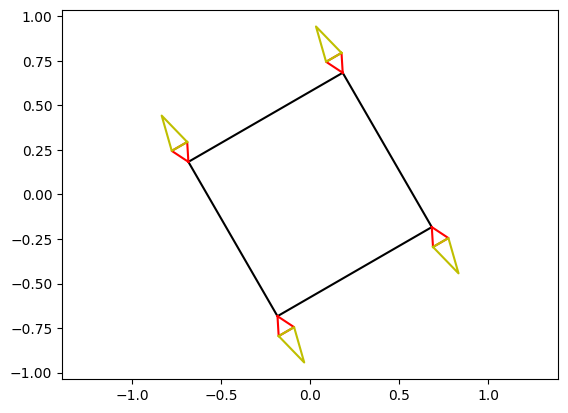

In [ ]:
import matplotlib.pyplot as plt

dist = 0.5
def offsetPos(geom,xpos, ypos, thpos):
    c = np.cos(thpos)
    s = np.sin(thpos)
    rmat = np.array([[c, -s],
                     [s,  c]])
    geom = np.dot(rmat, geom.T).T
    geom[:,0] += xpos
    geom[:,1] += ypos
    return geom

satSquare = np.array([[dist, dist],
                     [dist, -dist],
                     [-dist, -dist],
                     [-dist, dist],
                     [dist, dist]])
tGeom = .2*np.array([[0, 0],
               [ .5*dist, dist],
               [-.5*dist, dist],
               [       0,    0]])

plume = .2*np.array([[.5*dist, dist],
                     [0, 3*dist],
                     [-.5*dist, dist],
                     [.5*dist, dist]])

ta = -tGeom + np.array([[dist, -dist],
                        [dist, -dist],
                        [dist, -dist],
                        [dist, -dist]])
tb = -tGeom + np.array([[-dist, -dist],
                        [-dist, -dist],
                        [-dist, -dist],
                        [-dist, -dist]])
tc =  tGeom + np.array([[-dist, dist],
                        [-dist, dist],
                        [-dist, dist],
                        [-dist, dist]])
td =  tGeom + np.array([[dist, dist],
                        [dist, dist],
                        [dist, dist],
                        [dist, dist]])
pa =-plume + np.array([[dist, -dist],
                       [dist, -dist],
                       [dist, -dist],
                       [dist, -dist]])
pb =-plume + np.array([[-dist, -dist],
                       [-dist, -dist],  
                       [-dist, -dist],
                       [-dist, -dist]])
pc = plume + np.array([[-dist, dist],
                       [-dist, dist],
                       [-dist, dist],
                       [-dist, dist]])
pd = plume + np.array([[dist, dist],
                       [dist, dist],
                       [dist, dist],
                       [dist, dist]])   
theta = 30. * np.pi / 180.
c = np.cos(theta)
s = np.sin(theta)
rmat = np.array([[c, -s],
                 [s,  c]])
satSquare = np.dot(rmat, satSquare.T).T
ta = np.dot(rmat, ta.T).T
tb = np.dot(rmat, tb.T).T
tc = np.dot(rmat, tc.T).T
td = np.dot(rmat, td.T).T
pa = np.dot(rmat, pa.T).T
pb = np.dot(rmat, pb.T).T
pc = np.dot(rmat, pc.T).T   
pd = np.dot(rmat, pd.T).T
plt.plot(satSquare[:,0], satSquare[:,1], 'k-')
plt.plot(ta[:,0], ta[:,1], 'r-')
plt.plot(tb[:,0], tb[:,1], 'r-')
plt.plot(tc[:,0], tc[:,1], 'r-')
plt.plot(td[:,0], td[:,1], 'r-')
plt.plot(pa[:,0], pa[:,1], 'y-')
plt.plot(pb[:,0], pb[:,1], 'y-')
plt.plot(pc[:,0], pc[:,1], 'y-')
plt.plot(pd[:,0], pd[:,1], 'y-')


plt.axis('equal')
plt.show()

(-0.9717889427565842,
 5.544959176027886,
 -0.3139411196570008,
 8.489741462027958)

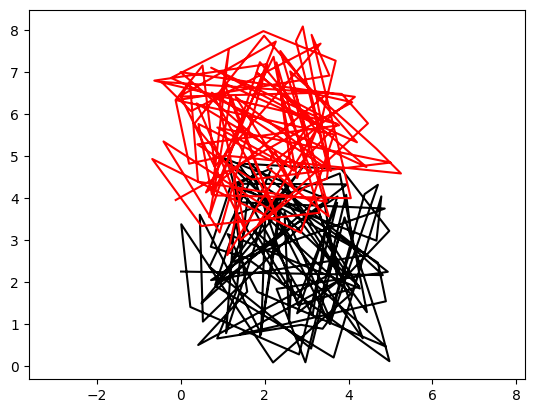

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# geom = np.array([[1, 0],
#                  [0, 1],
#                  [-1, 0],
#                  [0, -1],   
#                  [1, 0]])
geom = 5*np.random.rand(100,2)

def offsetPos(geom,xpos, ypos, thpos):
    c = np.cos(thpos)
    s = np.sin(thpos)
    geomTmp = np.dot(np.array([[c, -s],[s,  c]]), geom.T).T
    geomTmp  = geomTmp + xpos*np.array([np.ones(geom.shape[0]), np.zeros(geom.shape[0])]).T + ypos*np.array([np.zeros(geom.shape[0]), np.ones(geom.shape[0])]).T
    return geomTmp

gemoOff = offsetPos(geom, 1, 2, 30*np.pi/180.)
plt.plot(geom[:,0], geom[:,1], 'k-')
plt.plot(gemoOff[:,0], gemoOff[:,1], 'r-')
plt.axis('equal')

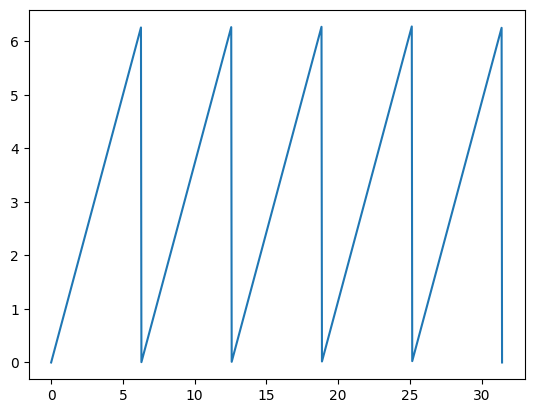

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def func(x):
    return np.mod(x, 2*np.pi)
x = np.linspace(0, 10*np.pi, 1000)
y = func(x)

plt.plot(x, y)
plt.show()

r0 = 0.12
0.07634640984121799


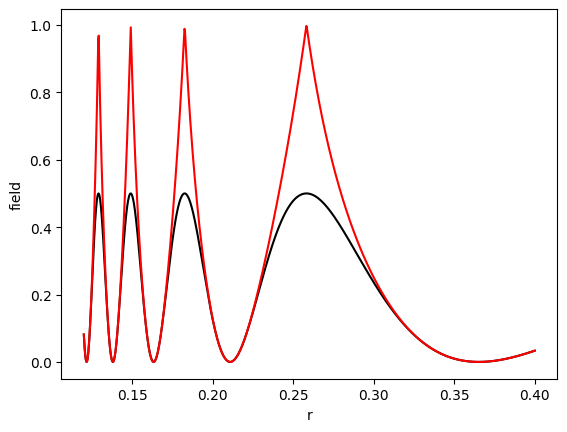

r
[0.12       0.14802803 0.17605606 0.20408408 0.23211211 0.26014014
 0.28816817 0.3161962  0.34422422 0.37225225]
ha
[1.95624929e-05 8.75956997e-03 1.64695843e-02 2.96043020e-02
 3.21078912e-02 5.02869081e-02 6.74235881e-02 7.40407886e-02
 7.58051143e-02 7.59342055e-02]


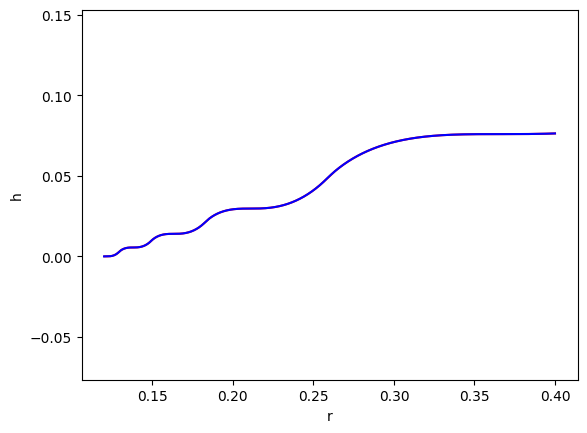

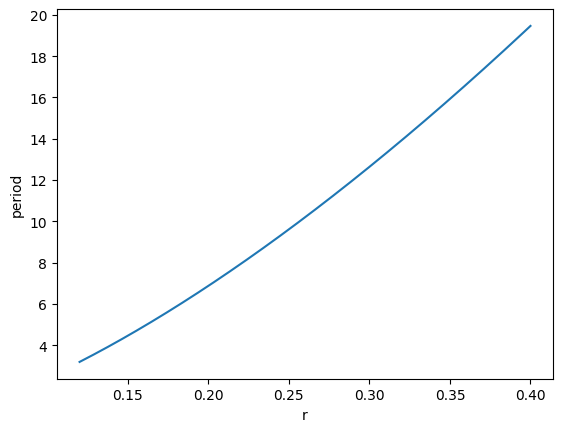

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as itg


#def fieldFuncGen(mp, g):
#    return lambda r: mp*g/r**2
def fieldFuncGen(mp, g):
    return lambda r: (1+np.cos(20*np.pi*mp*g/r**2))/4

def dhdtGen(fieldFunc):
    def dhdr(r):
        return np.tan(.5*np.arcsin(2*fieldFunc(r)))
    return dhdr

mp = 1e8
g = 6.67e-11

r0 = np.max([.12, (2*mp*g)**.5]) #(2*mp*g)**.5
print('r0 = {}'.format(r0))
r1 = .4
r = np.linspace(r0, r1, 1000)
v = (mp*g/r)**.5
w = v/r
period = 2*np.pi/w
fieldTmp = fieldFuncGen(mp, g)
dhdr = dhdtGen(fieldTmp)

ha = itg.cumulative_trapezoid(dhdr(r), r)
rb = np.linspace(r0, r1, 100000)
hb = itg.cumulative_trapezoid(dhdr(rb), rb)
print(np.max(ha))


plt.plot(r, fieldTmp(r),'k')
plt.plot(r, dhdr(r),'r')
plt.xlabel('r')
plt.ylabel('field')
plt.show()

print('r')
print(r[::100])
print('ha')
print(ha[::100])
plt.plot(r[1:], ha,'r')
plt.plot(rb[1:], hb,'b')
plt.xlabel('r')
plt.ylabel('h')
plt.axis('equal')
plt.show()


plt.plot(r, period)
plt.xlabel('r')
plt.ylabel('period')
plt.show()


In [ ]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt

def genV2Fun(m1,m2,v0,erg):
    def v2Fun(v2):
        return m1*((m1*v0**2 -m2*v2**2 - 2*erg)/m1) + m2*v2 -m1*v0
    return v2Fun

m1 = 1.
m2 = 1.
v0 = 10.
erg = 5.

vp = m1/(m1+m2)*v0
print('vp = {}'.format(vp))
emax = .5*(m1*v0**2 - (m1+m2)*vp**2)
print('emax = {}'.format(emax))

v2Fun = genV2Fun(m1,m2,v0,erg)
v2 = opt.fsolve(v2Fun, 1.)
print('v2 = {}'.format(v2)) 

v2 = [9.45823643]
